# Final Held-Out Test Set Evaluation

**Run once.** `quora_question_pairs_test.csv` (80,858 labeled pairs, provided separately by the course) has not been touched anywhere else in this project.

Model: **Model 3** (fine-tuned Sentence Transformer, bi-encoder) -- chosen per the README Conclusions as the production pick (validated at full scale, no per-call API dependency).

Threshold (0.60) is fixed from `04_sentence_transformers.ipynb` and **not** re-tuned here.

## Setup

In [7]:
import sys
sys.path.append('..')

In [8]:
import pandas as pd
from sklearn.metrics.pairwise import paired_cosine_distances
from sentence_transformers import SentenceTransformer

from src.evaluation import compute_metrics, append_to_experiment_table, plot_confusion_matrix

pd.set_option('display.max_colwidth', None)

## Load the test set (untouched until now)

In [9]:
test_df = pd.read_csv('/Users/nadiiababanska/Desktop/claude_coowork/ML_final_project/quora_question_pairs_test.csv')
print(len(test_df))
test_df['is_duplicate'].value_counts(normalize=True)

80858


is_duplicate
0    0.630797
1    0.369203
Name: proportion, dtype: float64

## Load the saved Model 3 and encode the test set

In [10]:
st_model = SentenceTransformer('/Users/nadiiababanska/Desktop/claude_coowork/ML_final_project/models/sentence_transformer_duplicate_model')

q1_emb_test = st_model.encode(test_df['question1'].tolist(), show_progress_bar=True)
q2_emb_test = st_model.encode(test_df['question2'].tolist(), show_progress_bar=True)

similarity_test = (1 - paired_cosine_distances(q1_emb_test, q2_emb_test)).clip(0, 1)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/2527 [00:00<?, ?it/s]

Batches:   0%|          | 0/2527 [00:00<?, ?it/s]

## Evaluate

Threshold fixed at 0.60 (chosen on train in `04_sentence_transformers.ipynb`), applied without modification.

model: Model 3 - Sentence Transformer (FINAL TEST SET)

threshold: 0.6

params: None

train_time_sec: None

train_f1: None

train_roc_auc: None

train_log_loss: None

f1: 0.824745926762381

roc_auc: 0.9359817531943184

log_loss: 0.34880331158638



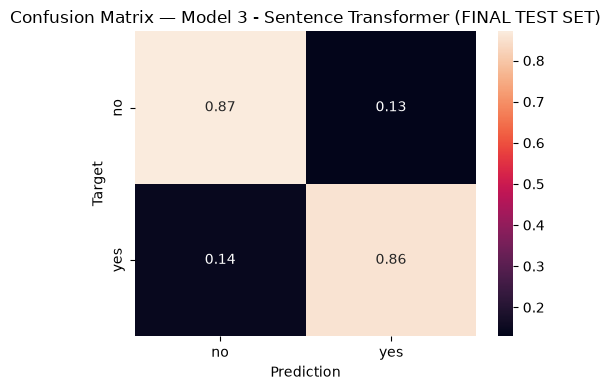

In [11]:
MODEL_3_THRESHOLD = 0.60

y_test = test_df['is_duplicate']
y_pred_test = (similarity_test > MODEL_3_THRESHOLD).astype(int)

results_test = compute_metrics(
    y_test, y_pred_test, similarity_test,
    'Model 3 - Sentence Transformer (FINAL TEST SET)',
    threshold=MODEL_3_THRESHOLD,
)

plot_confusion_matrix(y_test, y_pred_test, 'Model 3 - Sentence Transformer (FINAL TEST SET)')

append_to_experiment_table(results_test)

## Compare to validation performance

Val (Model 3 row in `reports/experiment_table.csv`): log loss 0.3483, F1 0.8251, ROC-AUC 0.9360.